In [ ]:
# Intro
# explore data and discuss goals

In [ ]:
# eda (exploratory data analysis)
# these are the packages we will need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# removes need to download locally, this is our dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
# file lacks column names, but there are the ones specified on source site corresponding to each column
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
# read in dataset with provided column names, specify that missing values are the '?' values
df = pd.read_csv(url, names=column_names, na_values="?")
# convert all numbers 1 to 4 into 1, leave 0's as 0 to become binary absence or presence of heart disease
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
# get broad overview of data - how many missing values, data type of column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [ ]:
# replace missing values with median of the column
df[['ca', 'thal']] = df[['ca', 'thal']].fillna(df[['ca', 'thal']].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


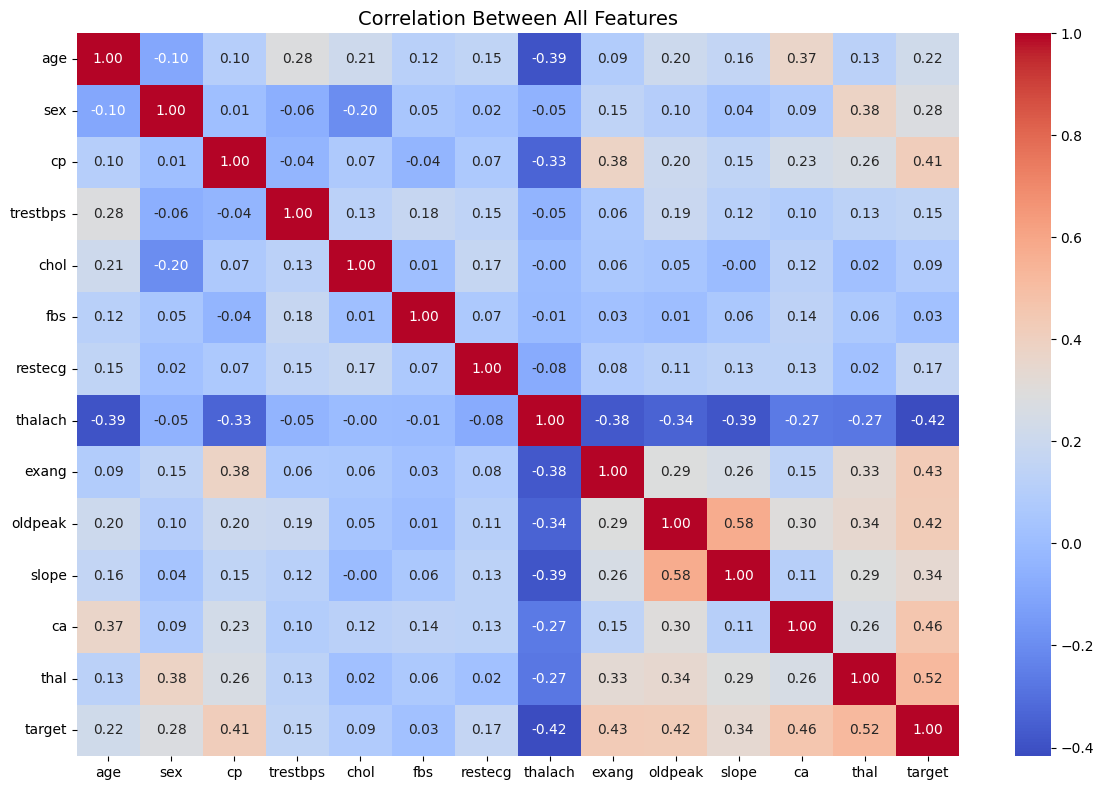

In [ ]:
# correlation heatmap to show why these features were chosen for analysis
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Between All Features", fontsize=14)
plt.tight_layout()
plt.show()

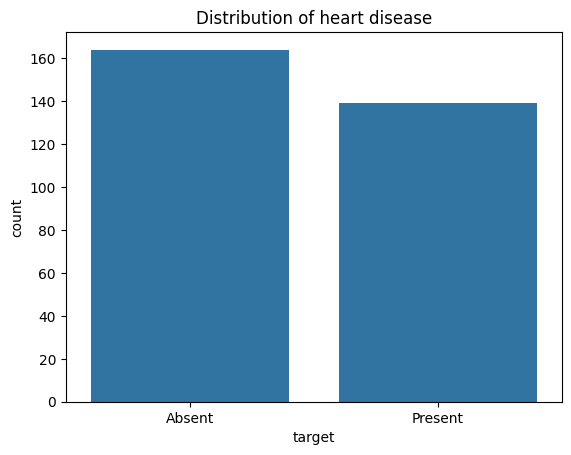

In [ ]:
# counts - check proportion of target values
sns.countplot(data=df, x='target')
plt.title('Distribution of heart disease')
plt.xticks([0, 1], ['Absent', 'Present'])
plt.show()

In [ ]:
# use random forest for training (jocelyn and shirley)
# !pip show pandas
# !pip show sci

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# separate features from target

# create matrix with just features to be used for prediction and leave out
# target, axis = 1 specifies variable to be dropped was a column
X = df.drop("target", axis=1)
# create vector for just the target variable
y = df["target"]

# split data: 20 percent for testing and 80 percent for learning
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# number of samples in the training data
num_samples = X_train.shape[0]

# calculate good estimate for value to use for max_depth
max_depth_value = int(np.log2(num_samples))

# create random forest model
rf = RandomForestClassifier(
    n_estimators=100, max_depth= max_depth_value, random_state=42,
)

# train random forest
rf.fit(X_train, y_train)

# make predictions on the testing data
y_pred = rf.predict(X_test)

# print report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.97      0.90        29
           1       0.96      0.84      0.90        32

    accuracy                           0.90        61
   macro avg       0.91      0.90      0.90        61
weighted avg       0.91      0.90      0.90        61



In [ ]:
# save and load the model for frontend
import joblib
joblib.dump(rf, 'heart_model.pkl')

['heart_model.pkl']

In [ ]:
# separate files used for this part through VS Code: app.py and train_model.py
# frontend (carolene and toyin and judith)
!pip install streamlit
!pip install requests

import streamlit as st
import requests as rq
import numpy as np

# if we move this part to a new location, will need the following:
@st.cache_resource # this is optional but keeps model in memory so it's faster than loading from hard drive every time run button
def load_model():
    try:
        return joblib.load('heart_model.pkl')
    except:
        return None

model = load_model() # can use this for the connection between button and model as the model

st.set_page_config(
    page_title = "Heart Disease Predictor",
    layout = "centered"
)


st.title(
    "Heart Disease Risk Predictor"
)

st.markdown(
    "This utilizes given information by the user such as their gender and chest pain type. We then send this information to our backend where it takes in the data and a result on whether you may or may not have a heart disease."
)


st.divider()

#Collecting the Variables Area

st.subheader("User Information (Make sure to input numbers ONLY)")

age = st.number_input(
    "Age",
    min_value = 0,
    max_value = 150
)

sex_number = st.number_input(
    "Sex (Male:1 and Female:0)",
    min_value = 0,
    max_value = 1
)

cp = st.number_input(
      "Chest Pain Type",
      min_value = 1,
      max_value = 4,
      help="Value 1: typical angina, Value 2: atypical angina, Value 3: non-anginal pain, Value 4: asymptomatic"
  )

trestbps = st.number_input(
    "Resting Blood Pressure (in mmHg)",
    min_value = 0,
    max_value = 10000,
    value = 120,
    help="Resting blood pressure (in mm Hg on admission to the hospital)"
)

chol = st.number_input(
    "Serum Cholestoral in mg/dl",
    min_value = 0,
    max_value = 10000,
    value = 200,
    help="A healthy cholesterol level is usually below 200 mg/dl. Values above 240 are considered high"
)

fbs = st.number_input(
    "Fasting Blood Sugar > 120 mg/dl",
    min_value = 0,
    max_value = 1,
    help="1 = True; 0 = False"
)

restecg = st.number_input(
    "Resting Electrocardiographic Results (0: Normal, 1: Abnormality, 2: Probable or Definite left Ventricular Hypertrophy)",
    min_value = 0,
    max_value = 1,
    value = 0,
    help="Value 0: Normal, Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria"
)

thalach = st.number_input(
    "Maximum Heart Rate Achieved",
    min_value = 0,
    max_value = 1000
)

exang = st.number_input(
    "Excersice Induced Angina (1 = yes; 0 = no)",
    min_value = 0,
    max_value = 1,
    help="Do you experience chest pain during exercise or physical activity?"
)

oldpeak = st.number_input(
    "ST Depression Induced by Exercise Relative to Rest",
    min_value = 0,
    max_value = 1000,
    value = 0,
    help="This measures how the heart's electrical activity changes under stress. (Higher numbers usually indicate more strain on the heart)"
)

slope = st.number_input(
    "The Slope of the Peak Exercise ST Segment",
    min_value = 1,
    max_value = 3,
    help = "Value 1: Upsloping, Value 2: flat, Value 3: Downward sloping"
)

ca = st.number_input(
    "Number of Major Vessels (0-3) colored by Flouropsy",
    min_value = 0,
    max_value = 3,
    #value = #Unknown
)

thal = st.number_input(
    "Thalassemia",
    min_value = 3,
    max_value = 7,
    help = "3 = Normal, 6 = Fixed Defect, 7 = Reversable Defect"
)


#Area to Trigger the Backend

def getting_result(age, sex, cp, trestbps, chol, fbs,
                   restecg, thalach, exang, oldpeak,
                   slope, ca, thal):
    if model is None:
        return "Model failed to load."

    # Must match training feature order EXACTLY
    input_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                           restecg, thalach, exang, oldpeak,
                           slope, ca, thal]])

    prediction = model.predict(input_data)[0]

    # Get probablity (Random Forest supports this)
    probability = model.predict_proba(input_data)[0][1]
    confidence = round(probability * 100, 2)

    if prediction == 1:
      return f"HIGH RISK of heart disease (Confidence: {confidence}%)"
    else:
      return f"LOW RISK of heart disease (Confidence: {confidence}%)"


if st.button("Submit"):
    try:
        result = getting_result(float(age),float(sex_number), float(cp),
                                float(trestbps), float(chol), float(fbs),
                                float(restecg), float(thalach), float(exang),
                                float(oldpeak), float(slope), float(ca), float(thal))
        st.success(f"The user has {result}")

    except Exception as e:
        st.error(f"Error: {e}")


2026-02-24 22:11:59.838 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-24 22:11:59.840 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-24 22:11:59.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-24 22:11:59.843 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-24 22:11:59.846 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-24 22:11:59.848 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-24 22:11:59.849 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-24 22:11:59.849 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Options for demo:
1) Run through Python in terminal
  1.1) check python version to make sure it's installed
  1.2) pip install streamlit
  1.3) create a file "app.py"
  1.4) paste full code from this notebook
  1.5) streamlit run app.py
2) Run on replit.com
  2.1) go to https://replit.com
  2.2) create a new Python project
  2.3) upload "app.py" and "heart_model.pkl"
  2.4) pip install streamlit
  2.5) streamlit run app.py --server.port 3000
3) Use VS Code
  3.1) open folder
  3.2) open terminal inside VS Code
  3.3) pip install streamlit
  3.4) streamlit run app.py

is it okay to use average for certain values? like of variables hard to get on your own without a medical visit? or how to use all the variables for frontend?